In [2]:
from ultralytics import YOLO
from pathlib import Path
import os

os.environ["YOLO_CONFIG_DIR"] = str(Path(".ultralytics_config").resolve())

model = YOLO("yolo26n-obb.pt")

results = model.predict(
    source="https://ultralytics.com/images/boats.jpg",
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    project="runs_obb",
    name="jupyter_predict_boats",
    exist_ok=True
)


image 1/1 E:\Jupyter Notebook\boats.jpg: 384x640 167 ships, 4 harbors, 146.9ms
Speed: 2.7ms preprocess, 146.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to E:\Jupyter Notebook\runs\obb\runs_obb\jupyter_predict_boats
1 label saved to E:\Jupyter Notebook\runs\obb\runs_obb\jupyter_predict_boats\labels


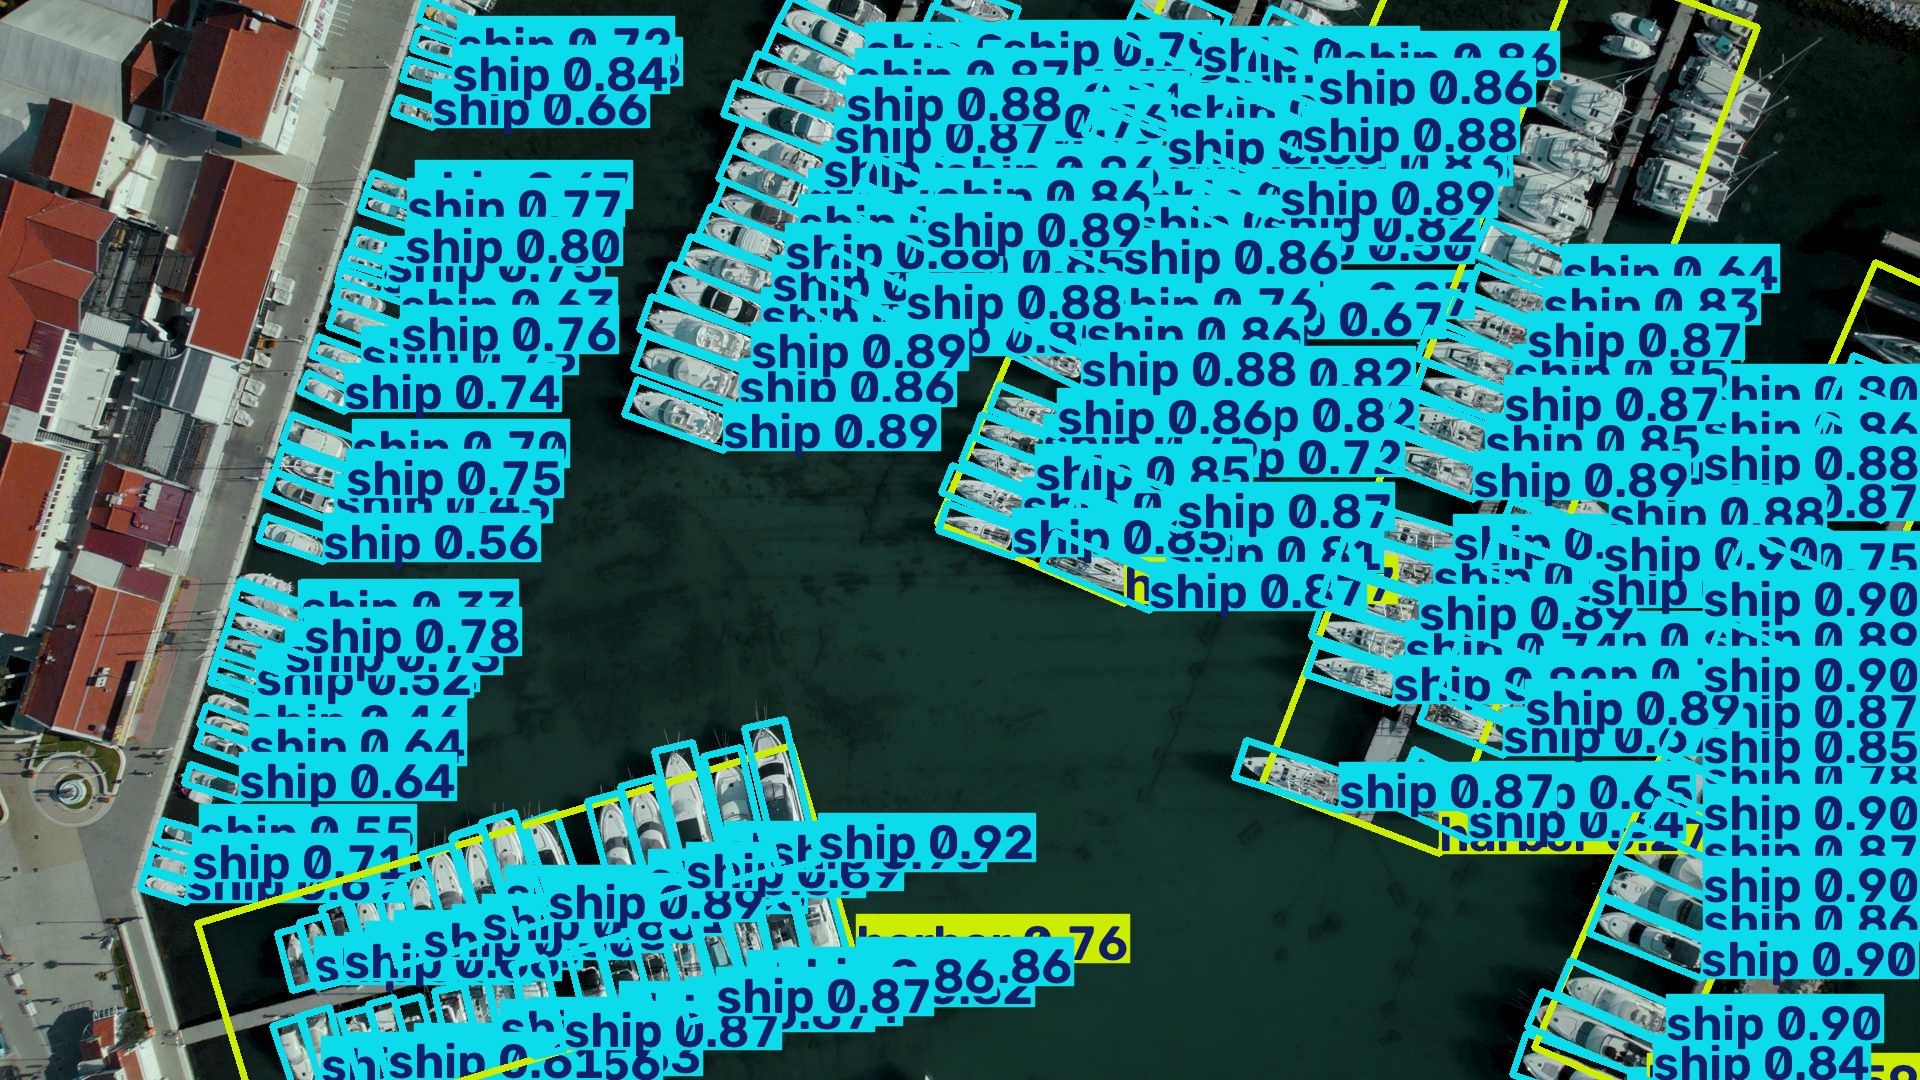

In [3]:
from IPython.display import Image, display
from pathlib import Path

result_dir = Path(results[0].save_dir)
display(Image(filename=str(result_dir / "boats.jpg")))

In [4]:
r = results[0]

print(r.obb.xywhr[:5])      # 中心点x、中心点y、宽、高、旋转角
print(r.obb.xyxyxyxy[:5])   # 四个角点
print(r.obb.cls[:5])        # 类别
print(r.obb.conf[:5])       # 置信度

tensor([[ 7.8136e+02,  7.9511e+02,  4.1049e+01,  1.4606e+02, -2.3338e-01],
        [ 1.6524e+03,  9.3935e+02,  1.2087e+02,  3.6164e+01,  3.8637e-01],
        [ 1.7935e+03,  5.7567e+02,  1.2091e+02,  3.6896e+01,  4.4221e-01],
        [ 1.6774e+03,  8.6446e+02,  1.1365e+02,  3.4697e+01,  4.3684e-01],
        [ 1.6187e+03,  1.0013e+03,  1.2097e+02,  3.6084e+01,  4.1681e-01]])
tensor([[[ 818.2197,  861.4156],
         [ 784.4415,  719.3193],
         [ 744.5049,  728.8127],
         [ 778.2831,  870.9090]],

        [[1701.5989,  978.8691],
         [1715.2263,  945.3713],
         [1603.2622,  899.8224],
         [1589.6348,  933.3202]],

        [[1840.2262,  618.2132],
         [1856.0155,  584.8659],
         [1746.7384,  533.1254],
         [1730.9491,  566.4727]],

        [[1721.5903,  904.2191],
         [1736.2700,  872.7802],
         [1633.2903,  824.6964],
         [1618.6106,  856.1354]],

        [[1666.6570, 1042.3231],
         [1681.2654, 1009.3284],
         [1570.6484,  

In [6]:
import os
from pathlib import Path

case_dir = Path(r"C:\Users\XZBbb\Desktop\高速车流量计数器\课件\yolo_obb案例复现")
os.chdir(case_dir)

print("当前目录：", Path.cwd())
print("yaml 是否存在：", Path("dota8_obb.yaml").exists())

当前目录： C:\Users\XZBbb\Desktop\高速车流量计数器\课件\yolo_obb案例复现
yaml 是否存在： True


In [7]:
model = YOLO("yolo26n-obb.pt")

train_results = model.train(
    data="dota8_obb.yaml",
    epochs=10,
    imgsz=640,
    batch=2,
    workers=0,
    project="runs_obb",
    name="jupyter_train_dota8",
    exist_ok=True
)

Ultralytics 8.4.106  Python-3.12.13 torch-2.13.0+cpu CPU (13th Gen Intel Core i9-13900H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dota8_obb.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=jupyter_train_dota8, nbs=64, nms=False, 

In [8]:
best_model = YOLO("runs/obb/runs_obb/jupyter_train_dota8/weights/best.pt")

metrics = best_model.val(
    data="dota8_obb.yaml",
    imgsz=640,
    project="runs_obb",
    name="jupyter_val_dota8",
    exist_ok=True
)

print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("mAP75:", metrics.box.map75)

Ultralytics 8.4.106  Python-3.12.13 torch-2.13.0+cpu CPU (13th Gen Intel Core i9-13900H)
YOLO26n-obb summary (fused): 132 layers, 2,449,332 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 424.955.0 MB/s, size: 97.3 KB)
val: Scanning E:\Jupyter Notebook\datasets\dota8\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3it/s 0.4s
                   all          4          8      0.978      0.968      0.995      0.839
      baseball diamond          3          4          1      0.905      0.995       0.89
      basketball court          1          3      0.933          1      0.995      0.929
     soccer ball field          1          1          1          1      0.995      0.697
Speed: 1.2ms preprocess, 88.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to C:\Users\XZBbb\Desktop\\\yolo_o